# 02 – EDA: Palmer Penguins
Numerische und kategoriale Merkmale, fehlende Werte, Gruppenvergleiche und Korrelationen. **Kein Modelltraining.** Datenlizenz: CC0.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def datenpfad(name):
    kandidaten = [Path("daten")/name, Path("set3-datenanalyse-und-visualisierung/daten")/name, Path("../daten")/name]
    return next(p for p in kandidaten if p.exists())

pinguine = pd.read_csv(datenpfad("palmer_penguins.csv"))
pinguine.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Struktur und Datenqualität

In [2]:
print("Form:", pinguine.shape)
print("\nDatentypen:\n", pinguine.dtypes)
print("\nFehlende Werte:\n", pinguine.isna().sum())
display(pinguine.describe(include="all").T)

Form: (344, 8)

Datentypen:
 species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

Fehlende Werte:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,344.0,NaN,NaN,NaN,2008.02907,0.818356,2007.0,2007.0,2008.0,2009.0,2009.0


Fehlende Werte werden nicht automatisch gelöscht. Für jedes Diagramm entscheidet pandas nur anhand der benötigten Spalten.

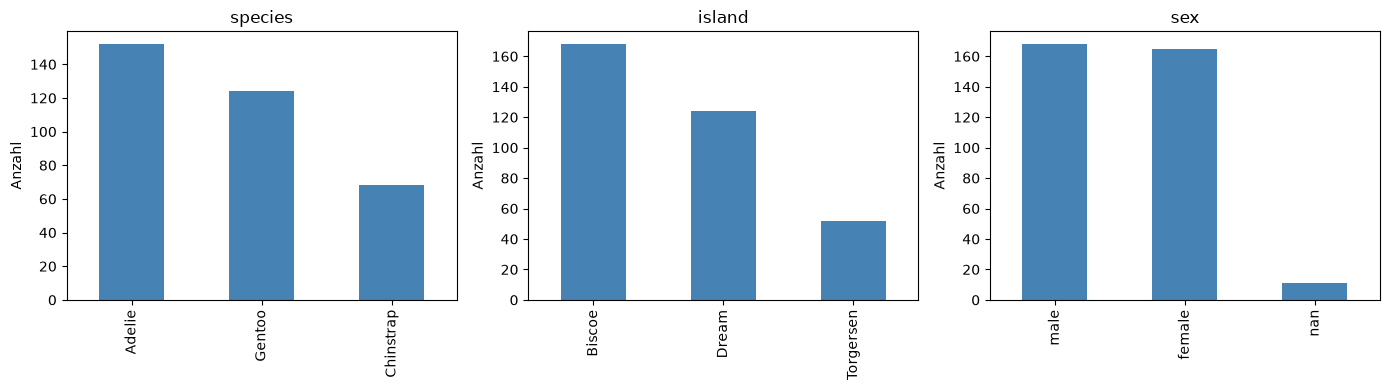

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, spalte in zip(axes, ["species", "island", "sex"]):
    pinguine[spalte].value_counts(dropna=False).plot.bar(ax=ax, color="steelblue")
    ax.set_title(spalte); ax.set_xlabel(""); ax.set_ylabel("Anzahl")
plt.tight_layout(); plt.show()

## Verteilungen und Gruppen

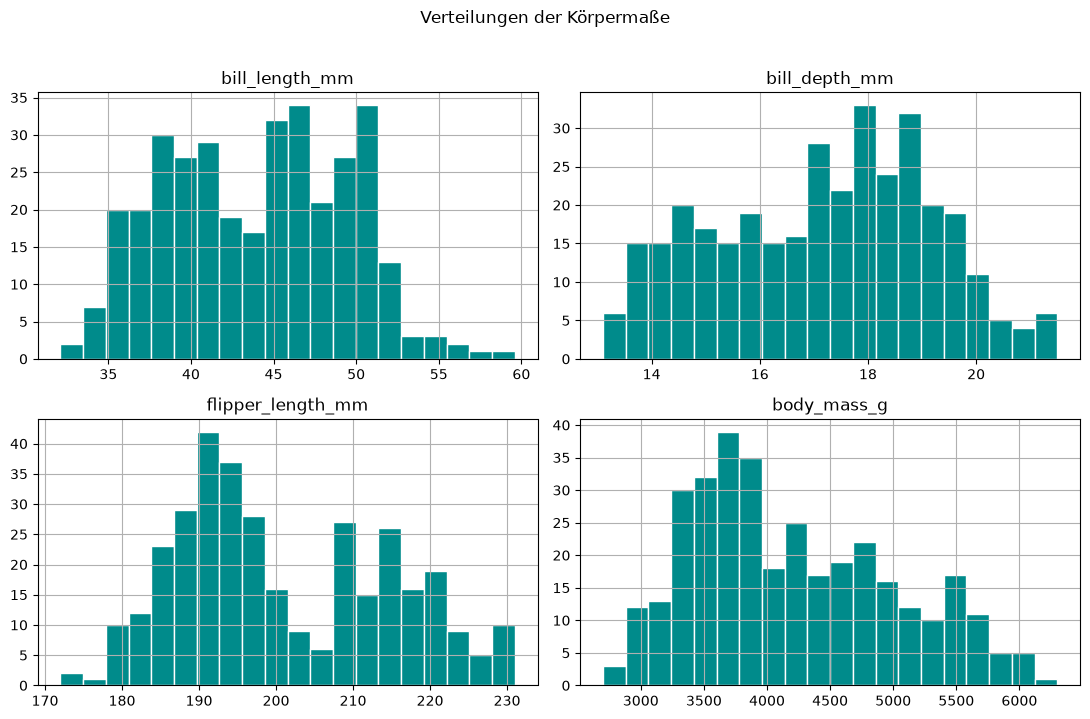

bill_length_mm              bill_depth_mm               \
                   count  mean median         count  mean median   
species                                                            
Adelie               151  38.8   38.8           151  18.3   18.4   
Chinstrap             68  48.8   49.6            68  18.4   18.4   
Gentoo               123  47.5   47.3           123  15.0   15.0   

          flipper_length_mm               body_mass_g                  
                      count   mean median       count    mean  median  
species                                                                
Adelie                  151  190.0  190.0         151  3700.7  3700.0  
Chinstrap                68  195.8  196.0          68  3733.1  3700.0  
Gentoo                  123  217.2  216.0         123  5076.0  5000.0

In [4]:
numerisch = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
pinguine[numerisch].hist(figsize=(11, 7), bins=20, color="darkcyan", edgecolor="white")
plt.suptitle("Verteilungen der Körpermaße", y=1.02); plt.tight_layout(); plt.show()

display(pinguine.groupby("species")[numerisch].agg(["count", "mean", "median"]).round(1))

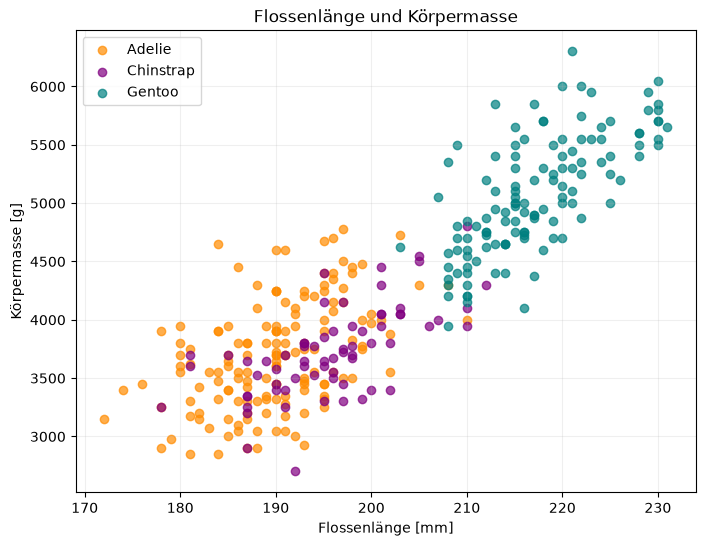

In [5]:
farben = {"Adelie":"darkorange", "Chinstrap":"purple", "Gentoo":"teal"}
fig, ax = plt.subplots(figsize=(8, 6))
for art, gruppe in pinguine.groupby("species"):
    ax.scatter(gruppe["flipper_length_mm"], gruppe["body_mass_g"], label=art, alpha=.7, color=farben[art])
ax.set(title="Flossenlänge und Körpermasse", xlabel="Flossenlänge [mm]", ylabel="Körpermasse [g]")
ax.legend(); ax.grid(alpha=.2); plt.show()

## Korrelationen

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


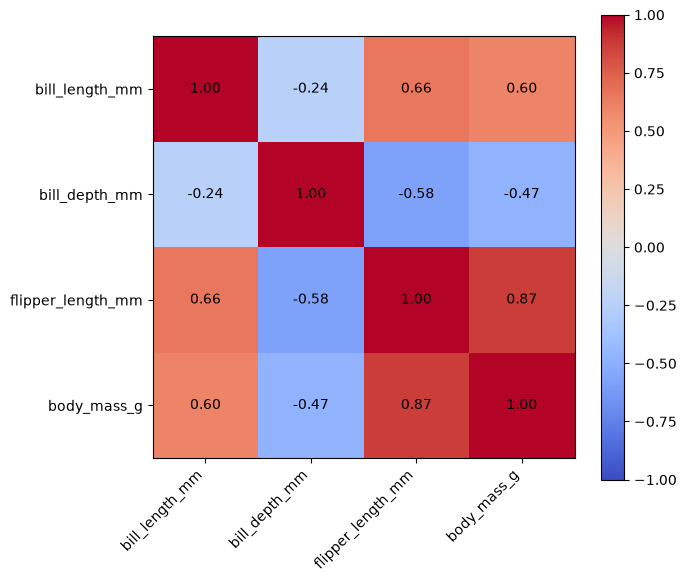

In [6]:
korrelation = pinguine[numerisch].corr()
display(korrelation.round(2))
fig, ax = plt.subplots(figsize=(7, 6))
bild = ax.imshow(korrelation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(4), numerisch, rotation=45, ha="right"); ax.set_yticks(range(4), numerisch)
for i in range(4):
    for j in range(4): ax.text(j, i, f"{korrelation.iloc[i,j]:.2f}", ha="center", va="center")
fig.colorbar(bild, ax=ax); plt.tight_layout(); plt.show()

Korrelation zeigt Zusammenhang, nicht Ursache. Gruppenunterschiede können die Gesamtkorrelation stark beeinflussen.